### Імпарт патрэбных бібліятэк

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction import FeatureHasher

### Адкрыццё файла

In [111]:
df = pd.read_csv("weather.csv", low_memory=False)

### Хуткі агляд звестак

In [112]:
df.head()
df.tail()
df.shape

(297627, 28)

Датасэт змяшчае 297627 радкоў назіранняў па 28 параметрах.

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297627 entries, 0 to 297626
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   datetime              297627 non-null  str    
 1   station_ru            297627 non-null  str    
 2   station_en            297627 non-null  str    
 3   lat_lon               297627 non-null  str    
 4   temperature           297517 non-null  float64
 5   pressure_station      289304 non-null  float64
 6   pressure_sea_level    293272 non-null  float64
 7   humidity              293374 non-null  float64
 8   wind_direction_ru     297316 non-null  str    
 9   wind_direction_en     234680 non-null  str    
 10  wind_direction_short  234680 non-null  str    
 11  wind_speed            297327 non-null  float64
 12  cloud_cover_ru        283239 non-null  str    
 13  cloud_cover_short     283239 non-null  str    
 14  weather_event_ru      117038 non-null  str    
 15  weather_eve

Звесткі прадстаўленыя як лікі з плавальнай кропкай (float64) і як радкі (str). 

Цікавыя назіранні:
1) Параметр lowest_clouds_height па логіцы мусіў бы быць float64, але насамрэч str. *Варта дататкова праверыць яго змесціва.*
2) Параметры хуткасці ветру (wind_direction_ru, _en, _short) маюць розную колькасць ненулявых радкоў, пры гэтым _en і _short — аднолькавую. Верагодна, скарачэнне робіцца ад англійскага варыянту. *Пропускі трэба будзе аднавіць, пераклаўшы з рускай.*



### Статыстыка лікавых (float64) параметраў

In [114]:
df.describe()

,temperature,pressure_station,pressure_sea_level,humidity,wind_speed,visibility,dewpoint_temperature,rainfall,rainfall_time,snow_cover_depth
count,297517.000000,289304.000000,293272.000000,293374.000000,297327.000000,286424.000000,284154.000000,39624.000000,39624.000000,8572.000000
mean,8.064581,746.273958,761.923984,76.606853,2.487463,10.497922,3.584799,2.054669,10.742782,11.519272
std,9.943566,7.603877,7.027484,18.579477,1.772224,6.758465,8.352088,6.027575,2.249209,10.710240
min,-30.600000,150.900000,723.300000,0.000000,0.000000,0.040000,-80.000000,0.000000,2.000000,0.000000
25%,0.800000,741.600000,757.600000,64.000000,1.000000,7.000000,-1.900000,0.010000,9.000000,3.000000
50%,7.700000,746.400000,761.900000,82.000000,2.000000,10.000000,3.800000,0.600000,12.000000,9.000000
75%,15.800000,751.200000,766.300000,92.000000,3.000000,10.000000,10.300000,2.000000,12.000000,17.000000
max,38.200000,781.000000,824.500000,100.000000,52.000000,71.000000,24.000000,900.000000,24.000000,67.000000


### Статыстыка тэкставых параметраў

In [115]:
df.describe(include="str")

,datetime,station_ru,station_en,lat_lon,wind_direction_ru,wind_direction_en,wind_direction_short,cloud_cover_ru,cloud_cover_short,weather_event_ru,weather_event_en,clouds_cl_ru,lowest_clouds_height,clouds_cm_ru,clouds_cm_en,clouds_cl_en,clouds_ch_ru,clouds_ch_en
count,297627,297627,297627,297627,297316,234680,234680,283239,283239,117038,116013,166435,187015,134025,134025,166435,118653,118653
unique,100563,7,7,7,18,18,18,970,13,500,10,10,10,10,10,10,10,10
top,01.04.2023 09:00,"Брест, аэропорт","Brest, airport","52.1112,23.8999","Штиль, безветрие","Calm, no wind","Calm, no wind",100%.,100,Дымка,Mist,"Слоисто-кучевые, образовавшиеся не из кучевых.","2500 and more, or no clouds","Высококучевых, высокослоистых или слоисто-дожд...","No Altocumulus, Altostratus or Nimbostratus.",Stratocumulus other than Stratocumulus cumulog...,"Перистых, перисто-кучевых или перисто-слоистых...","No Cirrus, Cirrocumulus or Cirrostratus."
freq,7,62720,62720,62720,31749,28407,28407,67457,89838,41472,41896,56660,57930,41412,41412,56660,44921,44921


### Пошук пропускаў

In [116]:
df.isnull().sum().sort_values(ascending=False)

snow_cover_depth        289055
rainfall                258003
rainfall_time           258003
weather_event_en        181614
weather_event_ru        180589
clouds_ch_ru            178974
clouds_ch_en            178974
clouds_cm_ru            163602
clouds_cm_en            163602
clouds_cl_en            131192
clouds_cl_ru            131192
lowest_clouds_height    110612
wind_direction_short     62947
wind_direction_en        62947
cloud_cover_short        14388
cloud_cover_ru           14388
dewpoint_temperature     13473
visibility               11203
pressure_station          8323
pressure_sea_level        4355
humidity                  4253
wind_direction_ru          311
wind_speed                 300
temperature                110
datetime                     0
station_ru                   0
station_en                   0
lat_lon                      0
dtype: int64

У датасэце прысутнічаюць пропускі. Частка з іх чаканая (напрыклад, snow_cover_depth запаўняецца толькі пры наяўнасці снегу), частка выкліканая недахопам звестак (напр., пропускі ў такіх параметрах як вільготнасць, ціск, бачнасць)

### Пошук дублікатаў

In [117]:
df.duplicated().sum()

np.int64(0)

Дублікатных звестак няма.

### Апрацоўка даты й часу

In [118]:
df["datetime"] = pd.to_datetime(df["datetime"], format="%d.%m.%Y %H:%M")

Для карэктнай працы з датай і часам неабходна ператварыць звесткі ў фармат datetime.

## Праца з пропускамі

### Выдаленне параметраў з занадта вялікай колькасцю пропускаў

In [119]:
df = df.drop(columns=["snow_cover_depth"])

Глыбіню снежнага покрыва ў даследванні ўлічваць немэтазгодна: занадта мала звестак, і яны не ўніверсальныя (актуальныя толькі ўзімку).

### Запаўненне пропускаў сярэднімі і медыяннымі значэннямі

In [120]:
df["temperature"] = df["temperature"].fillna(df["temperature"].mean())

df["pressure_station"] = df["pressure_station"].fillna(df["pressure_station"].median())

df["humidity"] = df["humidity"].fillna(df["humidity"].median())

df["wind_speed"] = df["wind_speed"].fillna(df["wind_speed"].median())

Для тэмпературы абранае сярэдняе значэнне, бо звесткі ня маюць моцных выбрасаў і размеркаванне прыблізна сіметрычнае. Для ціску, вільготнасці, хуткасці ветру выкарыстоўваецца медыяннае значэнне, бо звесткі асіметрычныя і могуць мець выбрасы.

### Запаўненне пропускаў у звестках пра ападкі

In [121]:
df["rainfall"] = df["rainfall"].fillna(0)

Будзем лічыць, што калі звестак пра ападкі няма, на станцыі ападкі не назіраліся, таму можна запоўніць нулямі.

### Запаўненне пропускаў у звесткаў пра надвор'е (weather_event)

#### Аднаўленне англійскіх значэнняў праз пераклад

In [122]:
# будуем слоўнік RU -> EN
mapping = (
    df[['weather_event_ru', 'weather_event_en']]
    .dropna(subset=['weather_event_ru', 'weather_event_en'])
    .drop_duplicates(subset='weather_event_ru')  # гарантируем уникальный индекс
    .set_index('weather_event_ru')['weather_event_en']
)

mapping

weather_event_ru
Дымка                                                                                                                                                         Mist
Состояние неба в общем не изменилось.                                                                                                       State of sky unchanged
Ливневый(ые) дождь(и) слабый(ые) в срок наблюдения или за последний час.                                                                                   Rain(s)
Дождь незамерзающий непрерывный слабый в срок наблюдения.                                                                                      Rain (not freezing)
Снег неливневый.                                                                                                                                              Snow
                                                                                                                                                     ...          
Ливне

In [123]:
df['weather_event_en'] = df['weather_event_en'].fillna(
    df['weather_event_ru'].map(mapping)
)

In [124]:
df[['weather_event_ru','weather_event_en']].isnull().sum()

weather_event_ru    180589
weather_event_en    181614
dtype: int64

#### Трэніроўка мадэлі для вызначэння weather_event праз іншыя параметры

In [125]:
features = [
    "temperature",
    "humidity",
    "pressure_sea_level",
    "wind_speed",
    "visibility",
    "dewpoint_temperature"
]

train = df[df["weather_event_en"].notna()]
test = df[df["weather_event_en"].isna()]

In [126]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(train[features], train["weather_event_en"])

df.loc[test.index, "weather_event_en"] = model.predict(test[features])

df["weather_event_en"].isnull().sum()

np.int64(0)

*Пропускаў weather_event_en больш не засталося.*

#### Запаўненне пустых па-руску на «-» каб пазбегнуць далейшай інтэрпрэтацыі як лік, а не радок.

In [127]:
df["weather_event_ru"] = df["weather_event_ru"].fillna("no_event")

### Асноўныя статыстычныя параметры

In [128]:
num_cols = df.select_dtypes(include=np.number)

stats = pd.DataFrame({
    "min": num_cols.min(),
    "max": num_cols.max(),
    "mean": num_cols.mean(),
    "median": num_cols.median(),
    "mode": num_cols.mode().iloc[0]
})

stats

,min,max,mean,median,mode
temperature,-30.60,38.2,8.064581,7.7,1.0
pressure_station,150.90,781.0,746.277483,746.4,746.4
pressure_sea_level,723.30,824.5,761.923984,761.9,761.2
humidity,0.00,100.0,76.683920,82.0,93.0
wind_speed,0.00,52.0,2.486972,2.0,2.0
visibility,0.04,71.0,10.497922,10.0,10.0
dewpoint_temperature,-80.00,24.0,3.584799,3.8,0.0
rainfall,0.00,900.0,0.273544,0.0,0.0
rainfall_time,2.00,24.0,10.742782,12.0,12.0


#### Перцэнтылі

In [129]:
num_cols.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,temperature,pressure_station,pressure_sea_level,humidity,wind_speed,visibility,dewpoint_temperature,rainfall,rainfall_time
0.05,-7.7,733.9,750.5,40.0,0.0,2.0,-10.9,0.0,3.0
0.25,0.8,741.7,757.6,65.0,1.0,7.0,-1.9,0.0,9.0
0.50,7.7,746.4,761.9,82.0,2.0,10.0,3.8,0.0,12.0
0.75,15.8,751.0,766.3,92.0,3.0,10.0,10.3,0.0,12.0
0.95,24.0,758.2,773.6,98.0,6.0,25.0,16.0,1.0,12.0


#### Дысперсія

In [130]:
num_cols.var()

temperature              98.837961
pressure_station         56.202499
pressure_sea_level       49.385532
humidity                340.673876
wind_speed                3.137852
visibility               45.676853
dewpoint_temperature     69.757382
rainfall                  5.324059
rainfall_time             5.058941
dtype: float64

#### Асіметрыя

In [131]:
num_cols.skew()

temperature              -0.054569
pressure_station         -1.831205
pressure_sea_level       -0.002134
humidity                 -0.843559
wind_speed                1.217550
visibility                1.923534
dewpoint_temperature     -0.424097
rainfall                203.765727
rainfall_time            -2.154676
dtype: float64

Анамалія паводле параметра rainfall.

#### Эксцэсы

In [132]:
num_cols.kurtosis()

temperature                -0.394838
pressure_station          134.140546
pressure_sea_level          0.730025
humidity                   -0.220497
wind_speed                  7.151504
visibility                  6.962507
dewpoint_temperature       -0.012544
rainfall                77749.874702
rainfall_time               4.634499
dtype: float64

Зноў анамальна высокі эксцэс для rainfall. 

## Feature Engineering

### Новыя параметры

#### Месяц назіранняў

In [133]:
df["month"] = df["datetime"].dt.month

Гэта можа быць карысна для адсочвання сезонных змен надвор'я.

#### Гадзіна назіранняў

In [134]:
df["hour"] = df["datetime"].dt.hour

Гэта можа быць карысна для адсочвання змен надвор'я на працягу дня.

#### Розніца ціску на станцыі й на ўзроўні мора

In [135]:
df["pressure_difference"] = df["pressure_sea_level"] - df["pressure_station"]

Верагодна, розніца ў ціску ў залежнасці ад вышыні мае карэляцыю з іншымі параметрамі.

### One-Hot Encoding

In [136]:
df_encoded = pd.get_dummies(df, columns=["wind_direction_short"])

Напрамак ветру можна разлажыць па напрамках, напрыклад: <br>
N / поўнач — (1, 0, 0, 0); <br>
E / усход — (0, 0, 0, 1); <br>
S / поўдзень — (0, 0, 1, 0);  <br>
W / захад — (0, 0, 0, 1).

### Label Encoding

In [137]:
le = LabelEncoder()

df["station_encoded"] = le.fit_transform(df["station_en"])

Станцыі можна прадставіць як лічбавы код.

### Feature Hashing

In [139]:
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=8, input_type="string")

hashed = hasher.transform(
    df["weather_event_ru"]
    .astype(str)
    .apply(lambda x: [x])
)

hashed_df = pd.DataFrame(hashed.toarray())

hashed_df.columns = [f"weather_hash_{i}" for i in range(hashed_df.shape[1])]

df = pd.concat([df, hashed_df], axis=1)

Дарэчна прыставаць як раз для апісанняў надвор'я: па-руску (weather_event_ru) яны вельмі розныя й несістэматызаваныя. Хэш-функцыя дапаможа зрабіць лаканічныя апісанні накшталт тых, што ёсць у зыходным датасэце па-англійску (weather_event_en).

## Візуалізацыя

### Гістаграма тэмпературы

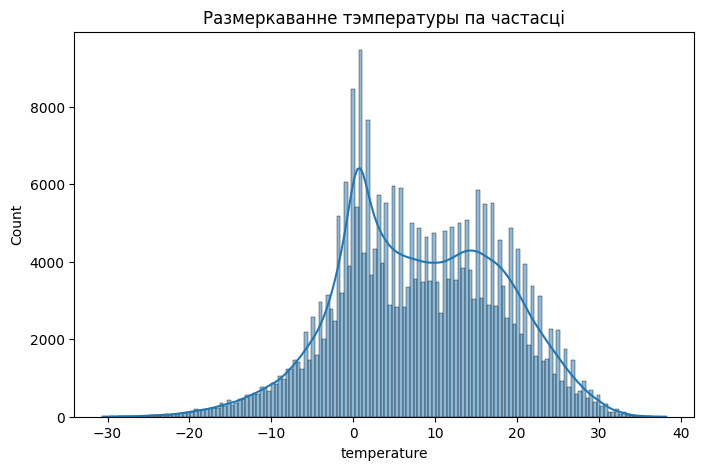

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["temperature"], kde=True)

plt.title("Размеркаванне тэмпературы па частасці")

plt.show()

### Праверка карэляцыі тэмпературы й вільготнасці праз scatterplot

<Axes: xlabel='temperature', ylabel='humidity'>

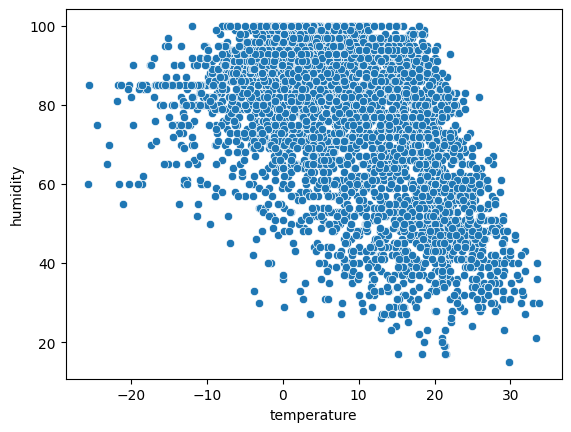

In [ ]:
sns.scatterplot(x="temperature", y="humidity", data=df.sample(5000))

Умераная адмоўная карэляцыя.

### Хуткасць ветру (скрыня з вусамі)

<Axes: xlabel='wind_speed'>

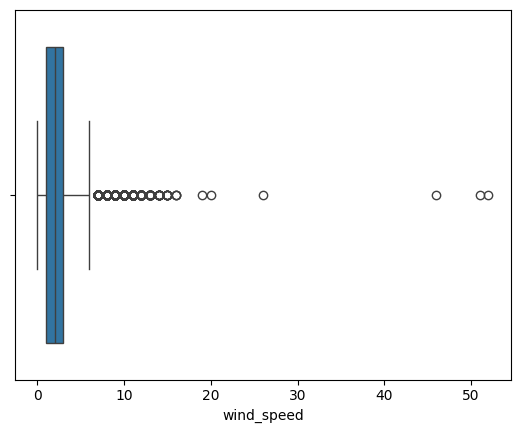

In [ ]:
sns.boxplot(x=df["wind_speed"])

Звычайна хуткасць ветру не перавышала 5-6 м/с, але здараўся анамальны вецер, ажно да 50 м/с.

### Матрыца карэляцый

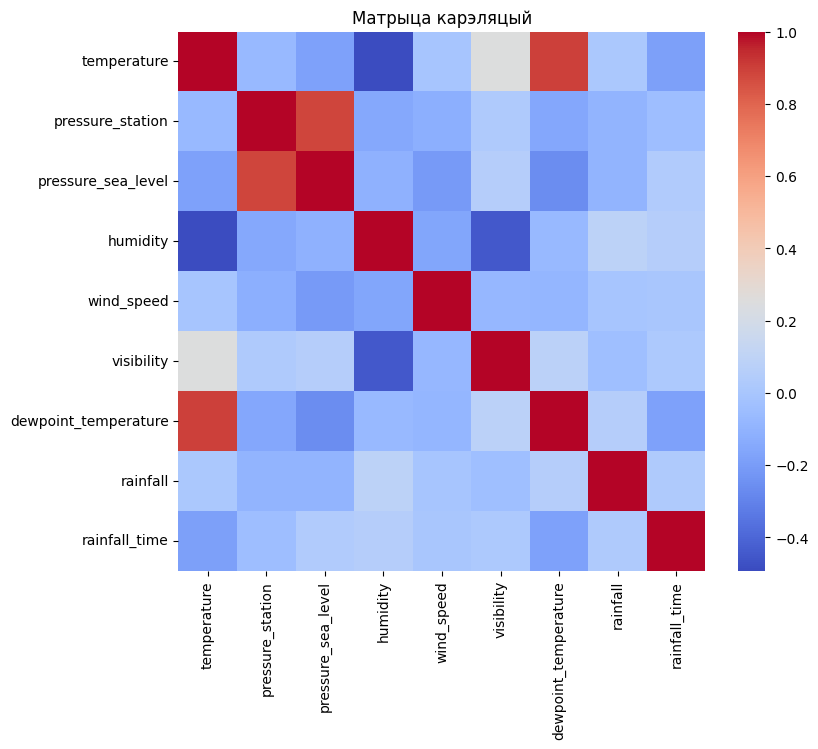

In [ ]:
corr = num_cols.corr()

plt.figure(figsize=(8.5,7))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Матрыца карэляцый")

plt.show()

Карэляцыя, канешне, назіраецца перш за ўсё паміж непасрэдна связанымі параметрамі:
- ціскам на станцыі й на ўзроўні мора;
- тэмпературай і пунктам расы;

З больш цікавых карэляцый абмежавана звязаныя:
- вільготнасць і бачнасць;
- вільготнасць і тэмпература.

### Сезонныя змены тэмпературы

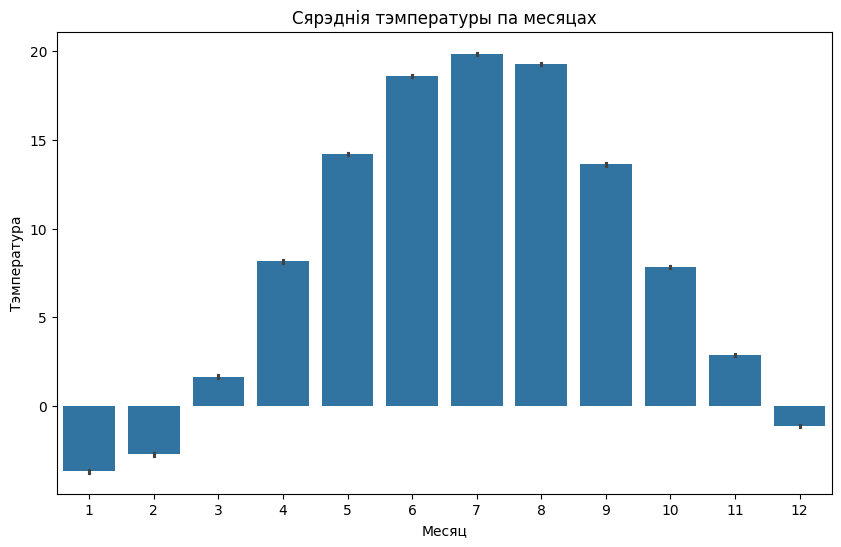

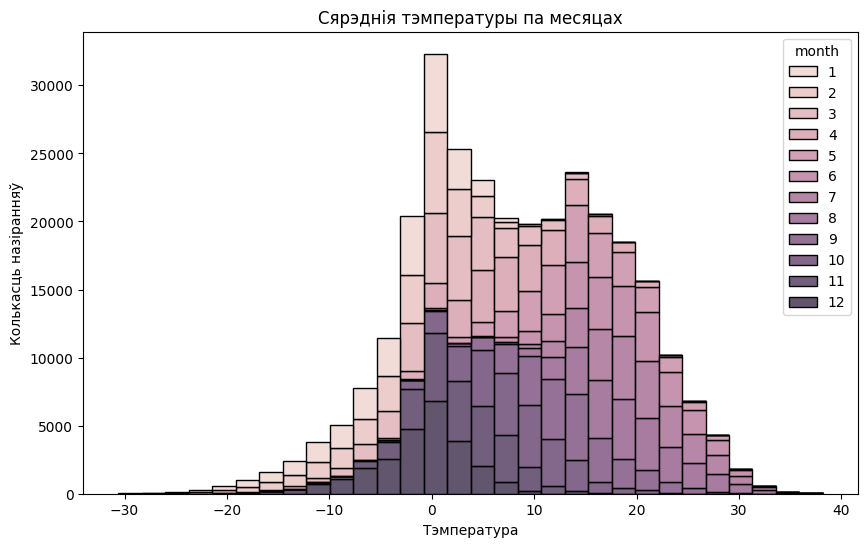

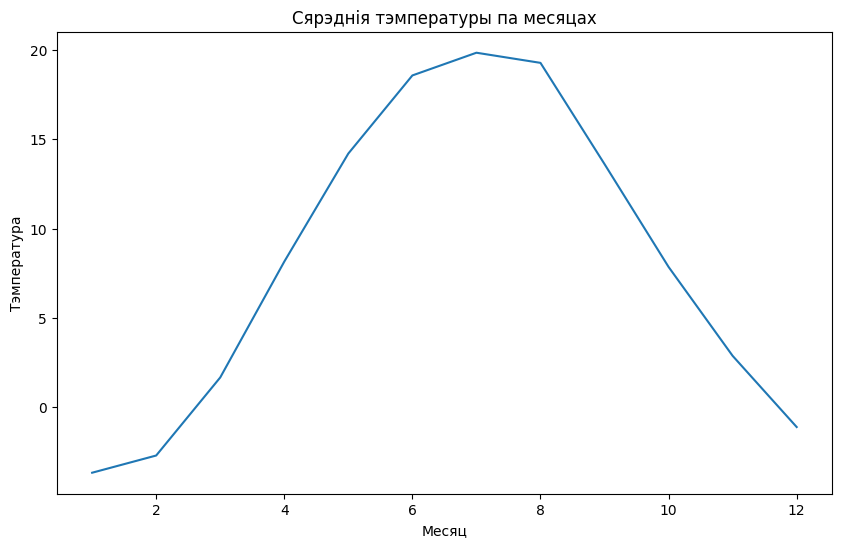

In [146]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="month",
    y="temperature",
    data=df,
    estimator="mean"
)

plt.title("Сярэднія тэмпературы па месяцах")
plt.xlabel("Месяц")
plt.ylabel("Тэмпература")

plt.show()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="temperature",
    hue="month",
    bins=30,
    multiple="stack"
)

plt.title("Сярэднія тэмпературы па месяцах")
plt.xlabel("Тэмпература")
plt.ylabel("Колькасць назіранняў")

plt.show()

monthly_temp = df.groupby("month")["temperature"].mean()

plt.figure(figsize=(10,6))
sns.lineplot(x=monthly_temp.index, y=monthly_temp.values)

plt.title("Сярэднія тэмпературы па месяцах")
plt.xlabel("Месяц")
plt.ylabel("Тэмпература")

plt.show()

### Дзённыя змены тэмпературы

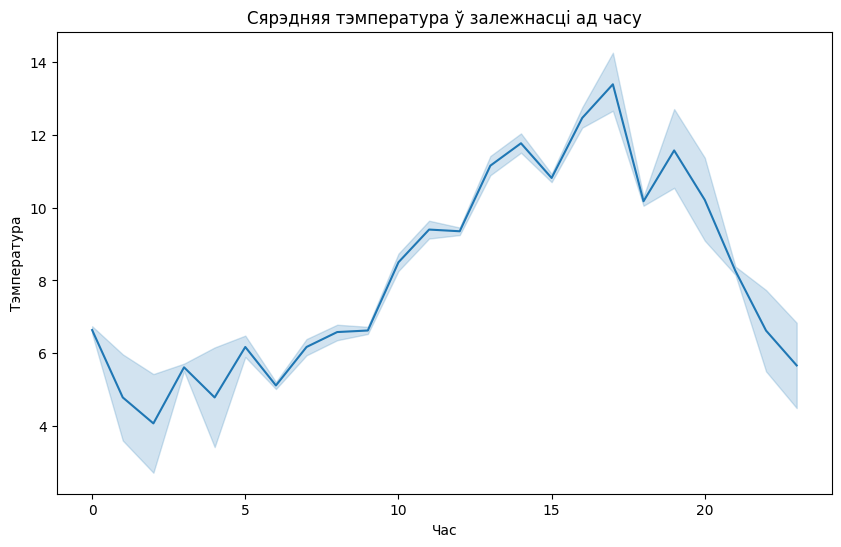

In [147]:
plt.figure(figsize=(10,6))
sns.lineplot(x="hour", y="temperature", data=df)

plt.title("Сярэдняя тэмпература ў залежнасці ад часу")
plt.xlabel("Час")
plt.ylabel("Тэмпература")

plt.show()


## Вынікі

### Асноўныя назіранні

- Датасэт змяшчае каля 300,000 назіранняў надвор'я
- Асноўныя прызнакі апісваюць тэмпературу, ціск, вільгаць, вецер.
- У некаторых радках назіраецца вялікая колькасць пропускаў.
- Размеркаванне тэмпературы блізкае да нармальнага.
- Назіраюцца сезонныя й дзённыя змены тэмпературы.

#### Магчымыя гіпотэзы

- Вільготнасць можа быць звязанай з наяўнасцю ападкаў. 
- Зніжэнне ціску можа ўказваць на пагаршэнне надвор'я.
- Хуткасць ветру можа павялічвацца падчас атмасферных фронтаў.

### Далейшыя крокі

- трэніроўка мадэлі прагназавання тэмпературы й іншых параметраў
- аналіз сезонных і дзённых заканамернасцяў
- пошукі іншых карэляцый і залежнасцяў

#### Выкарыстанне ШІ

ШІ выкарыстоўваўся для генерацыі прыкладаў кода, ідэй візуалізацыі, парадаў па структуры аналіза. Згенераваны код быў правераны й адаптаваны, а таксама пракаментаваны ўручную.